Starting Bat Algorithm simulation...
Iteration 100/1000, Best Fitness: 0.000000
Iteration 200/1000, Best Fitness: 0.000000
Iteration 300/1000, Best Fitness: 0.000000
Iteration 400/1000, Best Fitness: 0.000000
Iteration 500/1000, Best Fitness: 0.000000
Iteration 600/1000, Best Fitness: 0.000000
Iteration 700/1000, Best Fitness: 0.000000
Iteration 800/1000, Best Fitness: 0.000000
Iteration 900/1000, Best Fitness: 0.000000
Iteration 1000/1000, Best Fitness: 0.000000

Simulation finished.
Execution time: 3.95 seconds
--- Results ---
Best solution found (Position): [ 5.75132313e-05 -3.60097579e-05 -1.49722142e-04]
Best fitness found (Value): 2.7021194146956917e-08


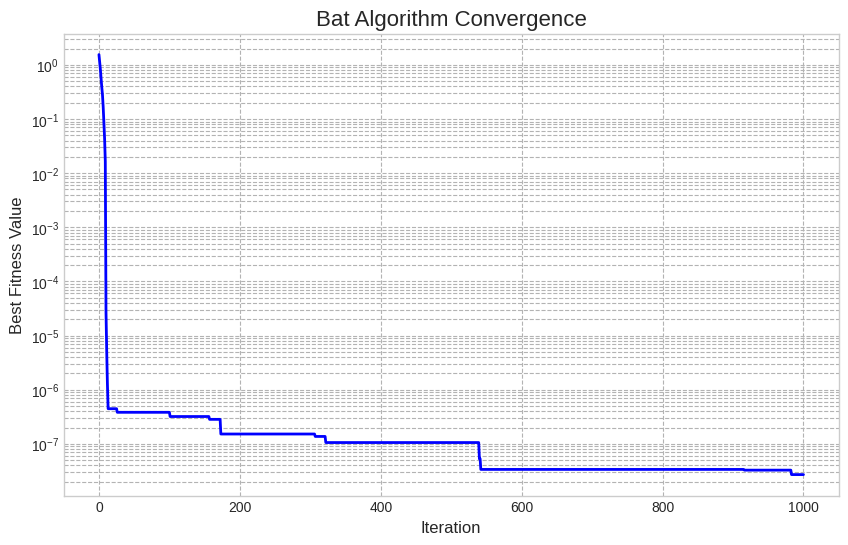

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

# --- Objective Function ---
# This is the function we want to minimize. It represents the "landscape"
# the bats are searching. We'll use a simple sphere function for this example.
# The minimum value is 0 at x_i = 0.
def objective_function(x):
    """Calculates the value of the sphere function."""
    return np.sum(x**2)

# --- Bat Algorithm Implementation ---
def bat_algorithm(n_bats, n_iterations, dim, lower_bound, upper_bound, f_min, f_max, A_initial, r_initial):
    """
    Implements the Bat Algorithm to find the minimum of an objective function.

    Args:
        n_bats (int): Number of bats in the population.
        n_iterations (int): Total number of iterations to run.
        dim (int): The number of dimensions in the search space.
        lower_bound (float): The lower boundary of the search space.
        upper_bound (float): The upper boundary of the search space.
        f_min (float): Minimum frequency.
        f_max (float): Maximum frequency.
        A_initial (float): Initial loudness for each bat.
        r_initial (float): Initial pulse emission rate for each bat.

    Returns:
        tuple: A tuple containing the best solution found (position) and its fitness value.
    """
    # --- Initialization ---
    # Parameters for updating loudness and pulse rate
    alpha = 0.9  # Loudness reduction factor
    gamma = 0.9  # Pulse rate increase factor

    # Initialize bat population: positions and velocities
    positions = np.random.uniform(lower_bound, upper_bound, (n_bats, dim))
    velocities = np.zeros((n_bats, dim))

    # Initialize frequencies, loudness, and pulse rates for each bat
    frequencies = np.zeros(n_bats)
    loudness = np.full(n_bats, A_initial)
    pulse_rates = np.full(n_bats, r_initial)

    # Evaluate initial population and find the best solution so far
    fitness = np.array([objective_function(p) for p in positions])
    best_index = np.argmin(fitness)
    best_position = positions[best_index]
    best_fitness = fitness[best_index]

    # Store convergence history for plotting
    convergence_curve = [best_fitness]

    # --- Main Loop ---
    for t in range(n_iterations):
        for i in range(n_bats):
            # --- 1. Global Search: Update bat position and velocity ---
            # Adjust frequency (controls the "jump" size)
            frequencies[i] = f_min + (f_max - f_min) * np.random.rand()

            # Update velocity
            velocities[i] += (positions[i] - best_position) * frequencies[i]

            # Update position (fly to a new location)
            new_position = positions[i] + velocities[i]

            # Apply bounds (ensure the bat stays within the search space)
            new_position = np.clip(new_position, lower_bound, upper_bound)

            # --- 2. Local Search: Generate a local solution ---
            # If a random number is greater than the pulse rate, perform a local search
            # around the current best solution. This is the exploitation phase.
            if np.random.rand() > pulse_rates[i]:
                # Generate a new solution by flying randomly around the best known position
                # The term `np.mean(loudness)` makes the random walk proportional to the average loudness
                # of the swarm. As bats get quieter (find better solutions), the local search becomes finer.
                new_position = best_position + 0.01 * np.random.randn(dim) * np.mean(loudness)
                new_position = np.clip(new_position, lower_bound, upper_bound)

            # --- 3. Evaluate and Update ---
            new_fitness = objective_function(new_position)

            # If we found a better solution AND the bat is "loud" enough (random check)
            if new_fitness < fitness[i] and np.random.rand() < loudness[i]:
                # Accept the new solution
                positions[i] = new_position
                fitness[i] = new_fitness

                # Update loudness and pulse rate (get quieter and pulse faster)
                loudness[i] *= alpha
                pulse_rates[i] = r_initial * (1 - np.exp(-gamma * t))

            # Update the global best solution if the current bat's new solution is better
            if new_fitness < best_fitness:
                best_position = new_position
                best_fitness = new_fitness

        # Record the best fitness for this iteration
        convergence_curve.append(best_fitness)
        if (t + 1) % 100 == 0:
            print(f"Iteration {t + 1}/{n_iterations}, Best Fitness: {best_fitness:.6f}")

    return best_position, best_fitness, convergence_curve


# --- Simulation Parameters ---
if __name__ == "__main__":
    # Problem definition
    DIMS = 3                # Number of dimensions
    LOWER_BOUND = -10.0     # Lower bound of the search space
    UPPER_BOUND = 10.0      # Upper bound of the search space

    # Algorithm parameters
    N_BATS = 50             # Number of bats
    N_ITERATIONS = 1000     # Number of iterations

    # Bat-specific parameters
    F_MIN = 0.0             # Minimum frequency
    F_MAX = 2.0             # Maximum frequency
    A_INITIAL = 1.0         # Initial loudness
    R_INITIAL = 0.1         # Initial pulse emission rate

    # Run the algorithm
    print("Starting Bat Algorithm simulation...")
    start_time = time.time()
    best_sol, best_fit, convergence = bat_algorithm(
        n_bats=N_BATS,
        n_iterations=N_ITERATIONS,
        dim=DIMS,
        lower_bound=LOWER_BOUND,
        upper_bound=UPPER_BOUND,
        f_min=F_MIN,
        f_max=F_MAX,
        A_initial=A_INITIAL,
        r_initial=R_INITIAL
    )
    end_time = time.time()
    print("\nSimulation finished.")
    print(f"Execution time: {end_time - start_time:.2f} seconds")
    print("--- Results ---")
    print(f"Best solution found (Position): {best_sol}")
    print(f"Best fitness found (Value): {best_fit}")

    # --- Plotting the results ---
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(convergence, color='b', linewidth=2)
    ax.set_title('Bat Algorithm Convergence', fontsize=16)
    ax.set_xlabel('Iteration', fontsize=12)
    ax.set_ylabel('Best Fitness Value', fontsize=12)
    ax.set_yscale('log') # Use a log scale to better see the improvement
    ax.grid(True, which="both", ls="--", c='0.7')
    plt.show()